# Analyzing Policy Impacts with Before/After Comparisons Between Groups

We can gain some leverage about policy effects by comparing changes in some outcome before an afte policy adoption and implementation between groups which adopted the policy and those that didn't. This general method is known as *difference in differences* (DiD or DD). The differencing used in the design allows units to have different starting values (time invariant values). As long the units are moving in parallel (parallel trends assumption), then we can use the untreated (no policy change) units' differences as estimates of the counterfactual for the treated units' differences (policy change). The design thus provides an estimate of the effect of the policy (known as the average treatment effect on the treated, or ATT).

In [4]:
# install.packages('pacman') 

pacman::p_load(
   tidyverse,    # for data wrangling
   did,         # for conducting did anlaysis
   lfe,         # for fixed effects models
   modelsummary # for regression tables
)

DiD is probably the most popular impact evaluation design. For this example, we will use quarterly data on bankruptcies by counties in MI, OH, and PA. The data are from the [U.S. Bankruptcy Court filings](https://www.uscourts.gov/statistics-reports/caseload-statistics-data-tables). Bankruptcy filings are the outcome variable, measured as the number of non-business bankruptcy filings per 1000 residents in the county. 

We are interested in seeing if the adoption of online casinos and legalized online sports betting caused increased bankruptcy filings in Pennsylvania (which launched online gambling in 2019) and Michigan (which launched in 2021). The control group is Ohio, which did not have legalized online gambling until 2023. Our quarterly data runs from 2017 through 2022. We will also use population and unemployment data by county from the 2020 Census and the American Community Survey. 

In [5]:
# read in the data from GitHub 
bankruptcy <- read_csv("https://raw.githubusercontent.com/bowendc/C2ER_NJDOL/refs/heads/main/bankruptcy.csv")

head(bankruptcy)

Rows: 6385 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (2): NAME.x, NAME.y
dbl (10): state_fips, county_fips, bus.bank, bank, time, adopt, pop, unemplo...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


# A tibble: 6 × 12
  state_fips county_fips bus.bank  bank  time adopt NAME.x            pop NAME.y
       <dbl>       <dbl>    <dbl> <dbl> <dbl> <dbl> <chr>           <dbl> <chr> 
1         39       39059        0     1     1     0 Guernsey Coun… 3.84e4 Guern…
2         42       42091        0     1     1    11 Montgomery Co… 8.57e5 Montg…
3         42       42077        0     1     1    11 Lehigh County… 3.75e5 Lehig…
4         42       42101        1     0     1    11 Philadelphia … 1.60e6 Phila…
5         39       39035        1     0     1     0 Cuyahoga Coun… 1.26e6 Cuyah…
6         39       39041        1     0     1     0 Delaware Coun… 2.14e5 Delaw…
# ℹ 3 more variables: unemployment <dbl>, bank.rate <dbl>, bus.bank.rate <dbl>

Let's just graph the relationship between bankruptcy and state, by quarter. 

`summarise()` has grouped output by 'state_fips'. You can override using the
`.groups` argument.


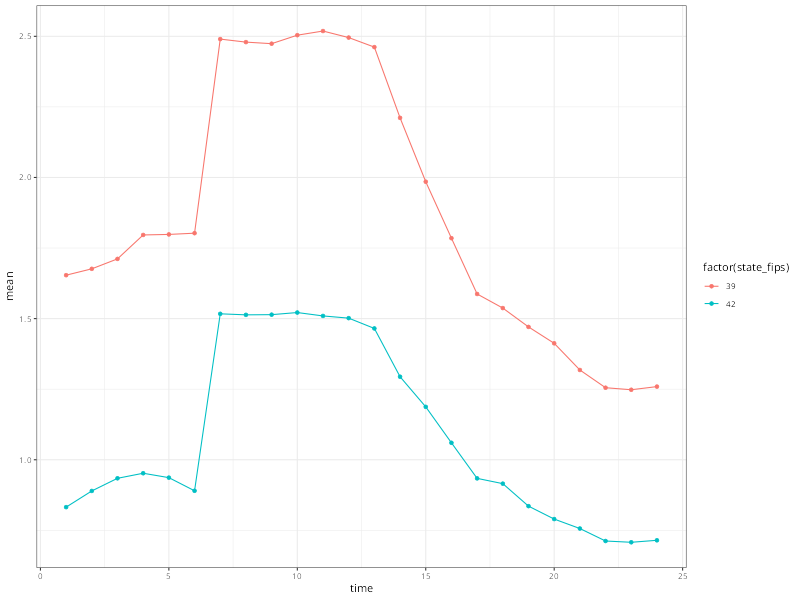

In [6]:
bankruptcy |> 
  filter(state_fips != "26") |>
  group_by(state_fips, time) |> 
  summarize(mean = mean(bank.rate, na.rm = TRUE))  |>
  ggplot(aes(x = time, y = mean, color = factor(state_fips))) +
  geom_line() + 
  geom_point() +
  theme_bw()

## $2 \times 2$ Comparisons

The classic $2 \times 2$ design has two groups and two time periods. We can generate the DiD estimates using OLS in two different ways. First, we can use a treated unit dummy, a post-treatment dummy, and an interaction term to model. The interaction term represents the ATT. Here, let's focus on just the PA and OH comparisons (we'll deal with MI later).

In [7]:
# estimate quick 2x2 dd model. Note that treat identifies all units who eventually
# adopt the policy with 1s, even prior to adoption. Post notes 
# all post-reform time periods.

# to create an interaction term, simply include the product of two variables: treat*post
# R will include both the constituent terms and the interaction term in the model.


bankruptcy <- bankruptcy |> 
  mutate(
    treat = if_else(state_fips == "42", 1, 0),  # PA units get treated 
    post = if_else(bankruptcy$time >= 11, 1, 0)  # all observations from quarter 11 on are post
  )

# felm is from the lfe package and lets us add fixed effects and/or clustered S.E. 
dd2x2 <- felm(bank.rate ~ treat*post
                | 0 | 0 | state_fips,     # value after first | shows var for FE (none here)
                                          # value after second | is for instrumental variables, leave as 0
                                          # value of third | is the variable on which you will calculate clustered S.E.s
                data = bankruptcy |> filter(state_fips!= "26" &
                                            time>=10 & time < 12) ) # drops all but two time periods and drops MI data

# view results. you could also use modelsummary
summary(dd2x2)

Warning message:
In chol.default(mat, pivot = TRUE, tol = tol) :
  the matrix is either rank-deficient or not positive definite



Call:
   felm(formula = bank.rate ~ treat * post | 0 | 0 | state_fips,      data = filter(bankruptcy, state_fips != "26" & time >= 10 &          time < 12)) 

Residuals:
     Min       1Q   Median       3Q      Max 
-2.05576 -0.43574 -0.02841  0.40119  2.20690 

Coefficients:
              Estimate Cluster s.e.    t value Pr(>|t|)    
(Intercept)  2.504e+00    6.311e-16  3.968e+15   <2e-16 ***
treat       -9.825e-01    7.350e-16 -1.337e+15   <2e-16 ***
post         1.466e-02    3.944e-16  3.717e+13   <2e-16 ***
treat:post  -2.665e-02    6.700e-16 -3.978e+13   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.7617 on 306 degrees of freedom
Multiple R-squared(full model): 0.2983   Adjusted R-squared: 0.2914 
Multiple R-squared(proj model): 0.2983   Adjusted R-squared: 0.2914 
F-statistic(full model, *iid*):43.36 on 3 and 306 DF, p-value: < 2.2e-16 
F-statistic(proj model): 5.956e+29 on 3 and 1 DF, p-value: 9.525e-16 



The regression results show that PA has almost 1 filling per 1000 county residents lower, on average, than Ohio. Counties in OH and PA have just .0147 more filings per 1000 residents in quarter 11 than in quarter 10 (PA is treated in quarter 11). The DiD estimate is represented in `treat:post`: this is how the `post` estimate changes for PA compared to OH: -.0267. This is a very small estimate and in the wrong direction (online gambling adoption is associated with lower bankruptcy rates). 

But we have many more time periods than 2! We can incorporate them into our estimate using two-way fixed-effects (TWFE). 

To conduct a TWFE DiD model over multiple time periods, we need to recode the treatment variable. This time, we will code all PA counties at quarter 11 and later as being "treated". Then we will use fixed effects for time and state to capture time period and group differences, respectively. 

In [8]:
# estimate fixed effects model (DD with multiple time periods)
# here, in the | time + state_fips | portion of the function,
# we specify the TWFE (time and state). The 0 part tells 
# R we are not using any instrumental variables. 
# the final | state_fips requests that we cluster standard 
# errors by state since we have repeated observations by 
# district over time. 

bankruptcy$treated = if_else(bankruptcy$state_fips == "42" & bankruptcy$time>=11, 1, 0)

ddTWFE.all <- felm(bank.rate ~ treated
                | time + state_fips | 0 | county_fips,
                data = bankruptcy |> filter(state_fips!= "26") )

summary(ddTWFE.all)


Call:
   felm(formula = bank.rate ~ treated | time + state_fips | 0 |      county_fips, data = filter(bankruptcy, state_fips != "26")) 

Residuals:
     Min       1Q   Median       3Q      Max 
-2.06592 -0.46733  0.02273  0.45669  3.09033 

Coefficients:
        Estimate Cluster s.e. t value Pr(>|t|)  
treated  0.14747      0.07476   1.973   0.0486 *
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.8364 on 4234 degrees of freedom
Multiple R-squared(full model): 0.2982   Adjusted R-squared: 0.2941 
Multiple R-squared(proj model): 0.001924   Adjusted R-squared: -0.00397 
F-statistic(full model, *iid*):71.98 on 25 and 4234 DF, p-value: < 2.2e-16 
F-statistic(proj model): 3.891 on 1 and 154 DF, p-value: 0.05034 



We can use the `att_gt` function from the **{did}** package to improve our estimate. `att_gt` will calculate "doubly robust" DD estimates

In [9]:
did <- att_gt(yname = "bank.rate",                    # outcome variable
              tname = "time",                         # time variable
              idname = "county_fips",                 # unit variable
              gname = "adopt",                        # variable that records first treated period by group
                                                      # OH counties coded 0 on this variable.
              allow_unbalanced_panel = TRUE,          # adjusts calculations for missing data in panel
              panel = TRUE,                           # the default is TRUE
              control_group = "nevertreated",         # alternative is 'notyettreated'
              data = bankruptcy |> filter(state_fips != "26") 
              )

summary(did)

You have an unbalanced panel. Proceeding as such.

Call:
att_gt(yname = "bank.rate", tname = "time", idname = "county_fips", 
    gname = "adopt", data = filter(bankruptcy, state_fips != 
        "26"), panel = TRUE, allow_unbalanced_panel = TRUE, control_group = "nevertreated")

Reference: Callaway, Brantly and Pedro H.C. Sant'Anna.  "Difference-in-Differences with Multiple Time Periods." Journal of Econometrics, Vol. 225, No. 2, pp. 200-230, 2021. <https://doi.org/10.1016/j.jeconom.2020.12.001>, <https://arxiv.org/abs/1803.09015> 

Group-Time Average Treatment Effects:
 Group Time ATT(g,t) Std. Error [95% Simult.  Conf. Band]  
    11    2   0.0349     0.0628       -0.1441      0.2138  
    11    3   0.0096     0.0664       -0.1795      0.1987  
    11    4  -0.0669     0.0619       -0.2433      0.1095  
    11    5  -0.0174     0.0727       -0.2244      0.1896  
    11    6  -0.0509     0.0644       -0.2344      0.1326  
    11    7  -0.0607     0.1254       -0.4179      0.2965  
  

The model output is best visualized using `ggdid` as an event study, which shows the difference between treatment and control units over time. 

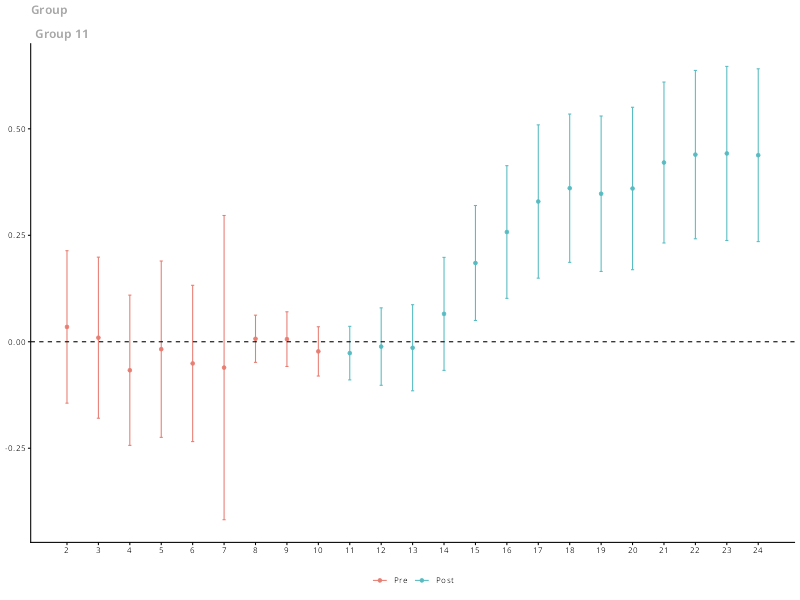

In [10]:
ggdid(did)

It takes a few quarters, but PA appears to see an increase in bankruptcy filings, compared to OH. 

We can average these estimates before and after treatment using `aggte`:

In [11]:
aggte(did, type = "simple")


Call:
aggte(MP = did, type = "simple")

Reference: Callaway, Brantly and Pedro H.C. Sant'Anna.  "Difference-in-Differences with Multiple Time Periods." Journal of Econometrics, Vol. 225, No. 2, pp. 200-230, 2021. <https://doi.org/10.1016/j.jeconom.2020.12.001>, <https://arxiv.org/abs/1803.09015> 


    ATT    Std. Error     [ 95%  Conf. Int.]  
 0.2567        0.0481     0.1624      0.3511 *


---
Signif. codes: `*' confidence band does not cover 0

Control Group:  Never Treated,  Anticipation Periods:  0
Estimation Method:  Doubly Robust

Here, we get a larger estimate of the effect of online gambling: .26 increase in filings per 1000 county residents. 

## DiD with differential timing (staggered timing)

The big benefit for using the **{did}** package is that we can handle staggered timing. Let's bring in our MI data.

You have an unbalanced panel. Proceeding as such.

Call:
att_gt(yname = "bank.rate", tname = "time", idname = "county_fips", 
    gname = "adopt", data = bankruptcy, panel = TRUE, allow_unbalanced_panel = TRUE, 
    control_group = "nevertreated")

Reference: Callaway, Brantly and Pedro H.C. Sant'Anna.  "Difference-in-Differences with Multiple Time Periods." Journal of Econometrics, Vol. 225, No. 2, pp. 200-230, 2021. <https://doi.org/10.1016/j.jeconom.2020.12.001>, <https://arxiv.org/abs/1803.09015> 

Group-Time Average Treatment Effects:
 Group Time ATT(g,t) Std. Error [95% Simult.  Conf. Band]  
    11    2   0.0349     0.0635       -0.1616      0.2313  
    11    3   0.0096     0.0662       -0.1954      0.2146  
    11    4  -0.0669     0.0533       -0.2317      0.0980  
    11    5  -0.0174     0.0676       -0.2268      0.1919  
    11    6  -0.0509     0.0635       -0.2475      0.1457  
    11    7  -0.0607     0.1281       -0.4570      0.3357  
    11    8   0.0071     0.0203   

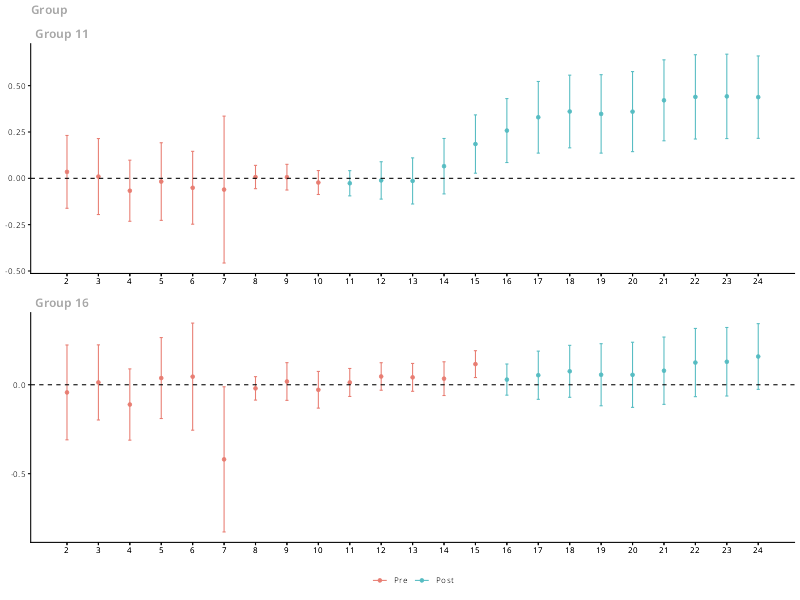

In [12]:
did.all <- att_gt(
  yname = "bank.rate",
  tname = "time",
  idname = "county_fips",
  gname = "adopt",
  allow_unbalanced_panel = TRUE,
  panel = TRUE,
  control_group = "nevertreated",
  data = bankruptcy
  )

summary(did.all)
ggdid(did.all)

Looks like our parallel trends assumption is less plausible for MI. Notice that we have two quarters with significantly different MI values from OH (Q7 and Q15). Not surprising, the p-value for pre-treatment parallel trends is significant, showing that we reject the null of parallel trends in the pre-treatment period. 

Let's work on improving our treatment and control county fit. First, we can focus just on the larger counties with more reliable data:

You have an unbalanced panel. Proceeding as such.

Call:
att_gt(yname = "bank.rate", tname = "time", idname = "county_fips", 
    gname = "adopt", data = filter(bankruptcy, pop >= 1e+05), 
    panel = TRUE, allow_unbalanced_panel = TRUE, control_group = "nevertreated")

Reference: Callaway, Brantly and Pedro H.C. Sant'Anna.  "Difference-in-Differences with Multiple Time Periods." Journal of Econometrics, Vol. 225, No. 2, pp. 200-230, 2021. <https://doi.org/10.1016/j.jeconom.2020.12.001>, <https://arxiv.org/abs/1803.09015> 

Group-Time Average Treatment Effects:
 Group Time ATT(g,t) Std. Error [95% Simult.  Conf. Band]  
    11    2   0.0270     0.1120       -0.2967      0.3507  
    11    3  -0.0612     0.1250       -0.4226      0.3002  
    11    4  -0.0621     0.1141       -0.3918      0.2676  
    11    5  -0.1012     0.1543       -0.5471      0.3448  
    11    6  -0.0504     0.1389       -0.4519      0.3511  
    11    7  -0.3277     0.2238       -0.9746      0.3193  
    11    8 

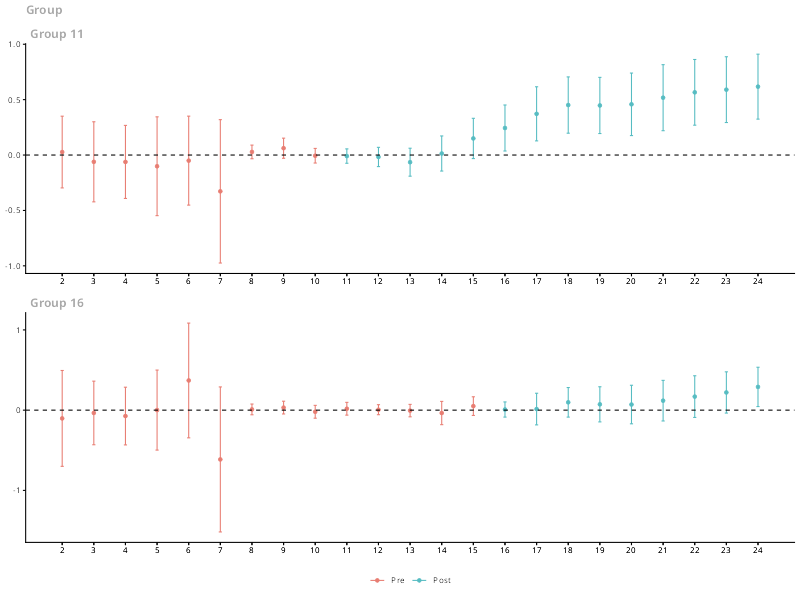

In [13]:
did.big <- att_gt(yname = "bank.rate",
                        tname = "time",
                        idname = "county_fips",
                        gname = "adopt",
                        allow_unbalanced_panel = TRUE,
                        panel = TRUE,
                        control_group = "nevertreated",
                        data = bankruptcy |> filter(pop >= 100000)
                        )

summary(did.big)
ggdid(did.big)

and now let's include predictors on which we think the parallel trends assumption might depend. Here, we use the unemployment rate from the ACS. 

You have an unbalanced panel. Proceeding as such.

Call:
att_gt(yname = "bank.rate", tname = "time", idname = "county_fips", 
    gname = "adopt", xformla = ~unemployment, data = filter(bankruptcy, 
        pop >= 1e+05), panel = TRUE, allow_unbalanced_panel = TRUE, 
    control_group = "nevertreated")

Reference: Callaway, Brantly and Pedro H.C. Sant'Anna.  "Difference-in-Differences with Multiple Time Periods." Journal of Econometrics, Vol. 225, No. 2, pp. 200-230, 2021. <https://doi.org/10.1016/j.jeconom.2020.12.001>, <https://arxiv.org/abs/1803.09015> 

Group-Time Average Treatment Effects:
 Group Time ATT(g,t) Std. Error [95% Simult.  Conf. Band]  
    11    2   0.0113     0.0980       -0.2682      0.2908  
    11    3  -0.1188     0.1577       -0.5687      0.3310  
    11    4  -0.0096     0.1255       -0.3676      0.3484  
    11    5  -0.1383     0.1454       -0.5529      0.2764  
    11    6  -0.0068     0.1537       -0.4452      0.4315  
    11    7  -0.3454     0.2360       

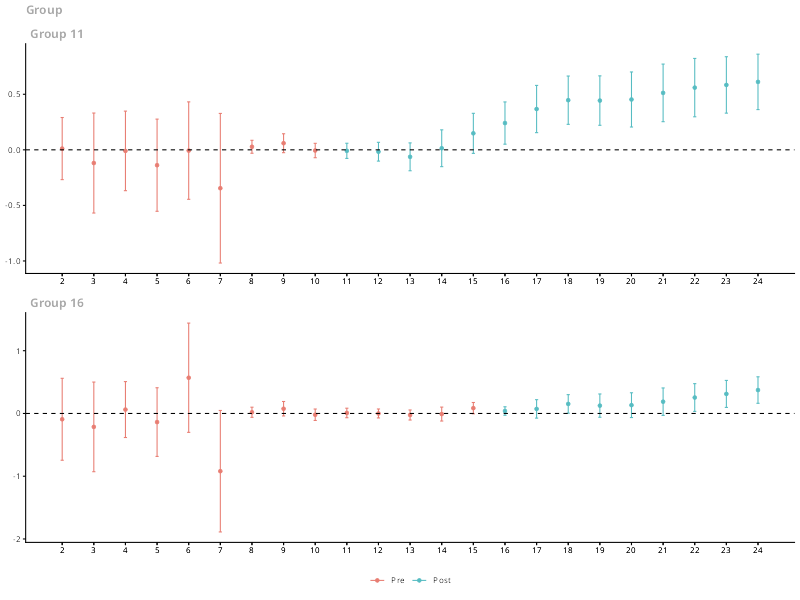

In [14]:
bankruptcy$lnpop <- log(bankruptcy$pop)
did.big2 <- att_gt(yname = "bank.rate",
                        tname = "time",
                        idname = "county_fips",
                        gname = "adopt",
                        allow_unbalanced_panel = TRUE,
                        panel = TRUE,
                        xformla = ~ unemployment, 
                        control_group = "nevertreated",
                        data = bankruptcy |> filter(pop >= 100000)
                        )

summary(did.big2)
ggdid(did.big2)

We can store and than call up the ATT for the post-treatment periods, again using `aggte`.

In [15]:
did.big2.simple <- aggte(did.big2, type = "simple")
did.big2.simple


Call:
aggte(MP = did.big2, type = "simple")

Reference: Callaway, Brantly and Pedro H.C. Sant'Anna.  "Difference-in-Differences with Multiple Time Periods." Journal of Econometrics, Vol. 225, No. 2, pp. 200-230, 2021. <https://doi.org/10.1016/j.jeconom.2020.12.001>, <https://arxiv.org/abs/1803.09015> 


    ATT    Std. Error     [ 95%  Conf. Int.]  
 0.2704        0.0484     0.1755      0.3653 *


---
Signif. codes: `*' confidence band does not cover 0

Control Group:  Never Treated,  Anticipation Periods:  0
Estimation Method:  Doubly Robust

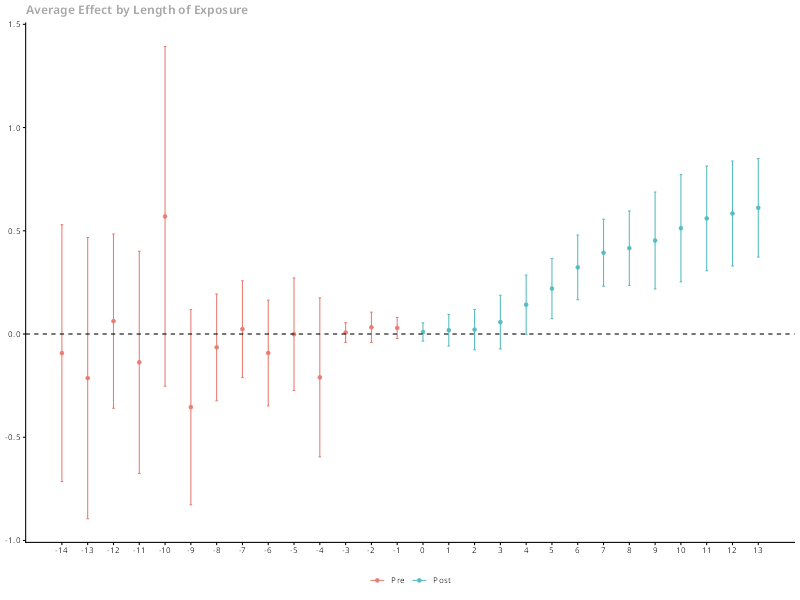

In [16]:
# the type = "dynamic" averages effects across groups by time since treated 
did.big2.dyn <- aggte(did.big2, type = "dynamic")
did.big2.dyn
ggdid(did.big2.dyn)



## Placebo tests with DiD

Placebo tests are excellent ways to establish validity of your research design. The general idea is that you can utilize your same design, but in a situation where you would *not* expect to see an effect of the policy treatment. In this case, let's swap out our non-business bankruptcy filing rate for a *business* bankruptcy filing rate. We should not expect online gambling to increase business bankruptcies in MI and PA. 

In [17]:
placebo <- att_gt(yname = "bus.bank.rate",
                        tname = "time",
                        idname = "county_fips",
                        gname = "adopt",
                        allow_unbalanced_panel = TRUE,
                        panel = TRUE,
                        xformla = ~ unemployment + pop,
                        control_group = "nevertreated",
                        data = bankruptcy |> filter(pop >= 100000)
                        )

placebo.simple <- aggte(placebo, type = "simple")
placebo.simple

You have an unbalanced panel. Proceeding as such.



Call:
aggte(MP = placebo, type = "simple")

Reference: Callaway, Brantly and Pedro H.C. Sant'Anna.  "Difference-in-Differences with Multiple Time Periods." Journal of Econometrics, Vol. 225, No. 2, pp. 200-230, 2021. <https://doi.org/10.1016/j.jeconom.2020.12.001>, <https://arxiv.org/abs/1803.09015> 


   ATT    Std. Error     [ 95%  Conf. Int.] 
 6e-04        0.0035    -0.0062      0.0074 


---
Signif. codes: `*' confidence band does not cover 0

Control Group:  Never Treated,  Anticipation Periods:  0
Estimation Method:  Doubly Robust

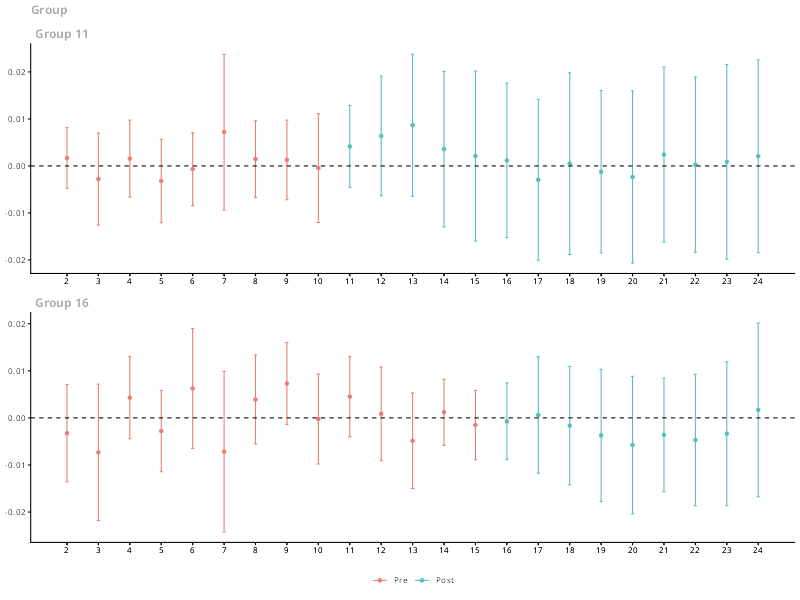

In [18]:
ggdid(placebo)

Sure enough, we find no evidence that online gambling increased business bankruptcy filing rates, and we do find evidence that it increased non-business bankruptcy filing rates per quarter. Let's present our ATTs in a quick table. 

In [19]:
modelsummary(list(did.big2.simple, placebo.simple))

Registered S3 method overwritten by 'broom':
  method    from
  nobs.felm lfe 


,(1),(2)
ATT(simple average),0.270,0.001
,(0.048),(0.003)
Num.Obs.,78,78
Std.Errors,by: county_fips,by: county_fips
type,simple,simple
ngroup,3,3
ntime,24,24
control.group,nevertreated,nevertreated
est.method,dr,dr
